Loading artifacts from /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz...


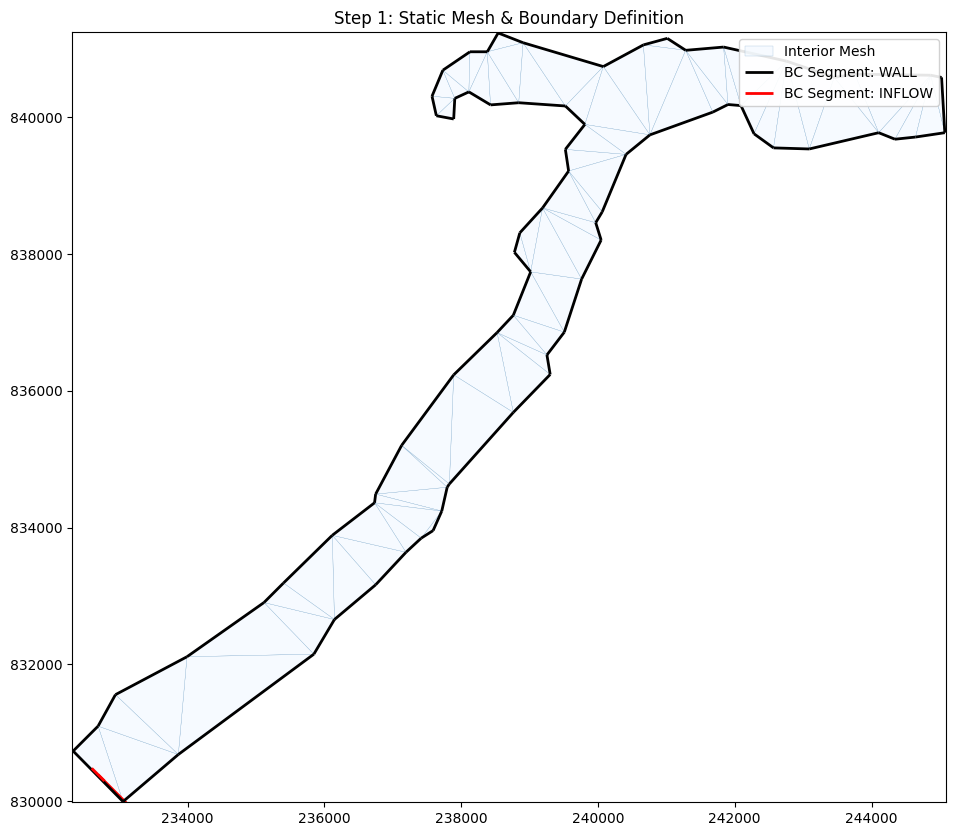

Initializing Sampler...
Adapting artifacts for Sampler compatibility...
  - Mapping bc_wall_starts to generic wall BC
  - Mapping bc_inflow_starts to inflow_starts
Loading sampler artifacts from: /tmp/tmpu810mtci.npz
  - Registered boundary 'wall': 74 segments
  - Registered boundary 'inflow': 1 segments
Sampling Interior...
Sampling General Boundaries (Walls)...


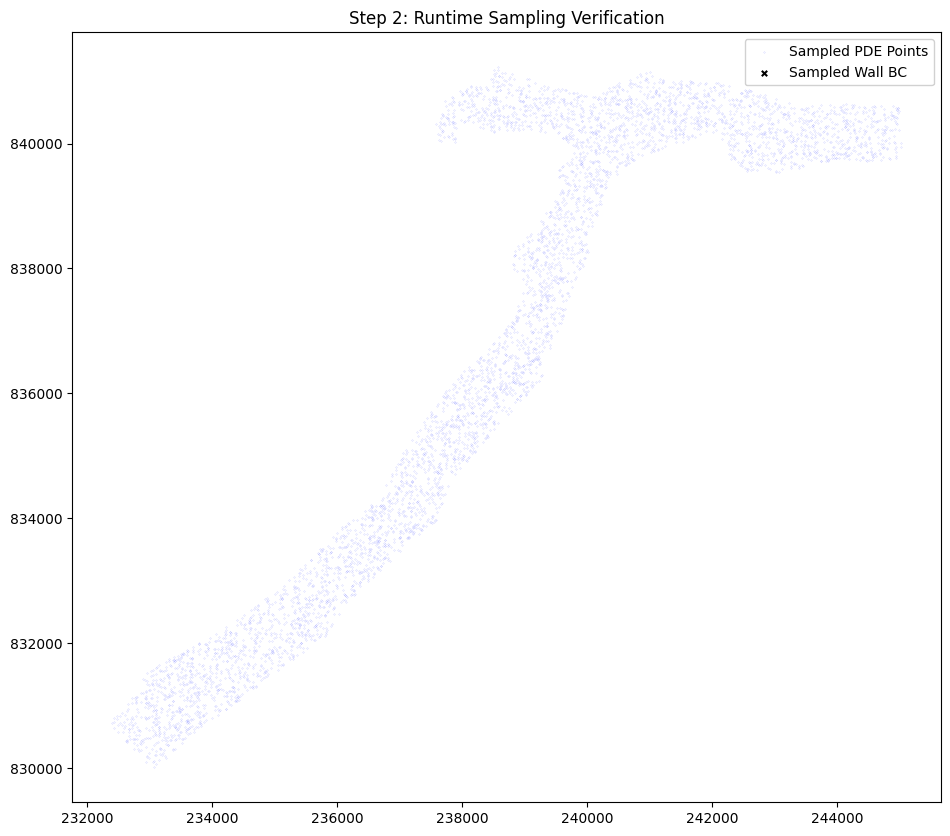

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection, LineCollection
import jax
import jax.numpy as jnp
import tempfile

# --- Setup Paths ---
# Add project root to path to import src
try:
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    project_root = "/workspaces/swe-pinn"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Manually set DTYPE for src.data
import src.config
src.config.DTYPE = jnp.float32

from src.data import IrregularDomainSampler

# Path to your artifacts
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz"

def create_legacy_compatible_artifacts(path):
    """
    Creates a temporary artifacts file that maps specific boundary types
    (e.g., bc_wall_starts) to the generic keys expected by IrregularDomainSampler 
    (bc_starts, inflow_starts).
    """
    print("Adapting artifacts for Sampler compatibility...")
    data = np.load(path)
    new_data = dict(data)
    
    # 1. Aggregating Walls (bc_starts)
    # The sampler expects 'bc_starts' and 'bc_vectors' for general walls.
    # We combine all bc_* that are NOT inflow.
    wall_starts = []
    wall_vectors = []
    
    found_any_wall = False
    
    if 'bc_starts' in data:
        # Already compatible
        return path 

    for key in data.files:
        if key.startswith("bc_") and key.endswith("_starts"):
            label = key[3:-7]
            if label == 'inflow':
                continue
            
            print(f"  - Mapping {key} to generic wall BC")
            wall_starts.append(data[f"bc_{label}_starts"])
            wall_vectors.append(data[f"bc_{label}_vectors"])
            found_any_wall = True

    if found_any_wall:
        new_data['bc_starts'] = np.concatenate(wall_starts, axis=0)
        new_data['bc_vectors'] = np.concatenate(wall_vectors, axis=0)

    # 2. Mapping Inflow (inflow_starts)
    # The sampler conditionally checks for 'inflow_starts'.
    if 'bc_inflow_starts' in data:
        print("  - Mapping bc_inflow_starts to inflow_starts")
        new_data['inflow_starts'] = data['bc_inflow_starts']
        new_data['inflow_vectors'] = data['bc_inflow_vectors']

    # Save to temp file
    fd, tmp_path = tempfile.mkstemp(suffix='.npz')
    os.close(fd)
    np.savez(tmp_path, **new_data)
    return tmp_path

def plot_mesh_and_boundaries(data):
    """
    Plots the static mesh (triangles) and all boundary segments found in the file.
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. Plot Interior Mesh (Triangles)
    tri_coords = data['tri_coords']
    mesh_col = PolyCollection(tri_coords, 
                              facecolors='aliceblue', 
                              edgecolors='steelblue', 
                              linewidths=0.2, 
                              alpha=0.6,
                              label='Interior Mesh')
    ax.add_collection(mesh_col)

    # 2. Plot Boundaries (Dynamic)
    colors = ['black', 'red', 'green', 'purple', 'orange'] # Color cycle for different BCs
    color_idx = 0
    
    # Scan for keys starting with 'bc_'
    for key in data.files:
        if key.startswith("bc_") and key.endswith("_starts"):
            label = key[3:-7] # extract 'wall', 'inflow', etc.
            
            starts = data[f"bc_{label}_starts"]
            vecs = data[f"bc_{label}_vectors"]
            ends = starts + vecs
            
            # Create segments [(x1,y1), (x2,y2)]
            segments = np.stack((starts, ends), axis=1)
            
            # Assign color
            c = colors[color_idx % len(colors)]
            
            # Plot
            lc = LineCollection(segments, colors=c, linewidths=2, label=f"BC Segment: {label.upper()}")
            ax.add_collection(lc)
            
            # Add arrows for Inflow to distinguish it
            if 'inflow' in label.lower():
                 mid = starts + vecs * 0.5
                 ax.quiver(mid[:,0], mid[:,1], vecs[:,0], vecs[:,1], color=c, scale=20, width=0.003)
            
            color_idx += 1

    # Formatting
    all_pts = tri_coords.reshape(-1, 2)
    ax.set_xlim(all_pts[:,0].min()-10, all_pts[:,0].max()+10)
    ax.set_ylim(all_pts[:,1].min()-10, all_pts[:,1].max()+10)
    ax.set_aspect('equal')
    ax.set_title("Step 1: Static Mesh & Boundary Definition")
    ax.legend(loc='upper right', framealpha=0.9)
    return fig

def plot_sampling_test(sampler):
    """
    Generates samples using the sampler and plots them.
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    key = jax.random.PRNGKey(42)
    k_pde, k_bc = jax.random.split(key)
    
    # 1. Sample Interior (PDE)
    print("Sampling Interior...")
    pde_pts = sampler.sample_interior(k_pde, n_points=5000, t_bounds=(0,1))
    
    ax.scatter(pde_pts[:,0], pde_pts[:,1], s=1, c='aliceblue', edgecolors='blue', linewidths=0.1, alpha=0.5, label='Sampled PDE Points')

    # 2. Sample General Boundaries (aggregated walls)
    print("Sampling General Boundaries (Walls)...")
    k_bc, k_sub = jax.random.split(k_bc)
    bc_pts = sampler.sample_boundary(k_sub, n_points=1000, t_bounds=(0,1), boundary_type='general')
    ax.scatter(bc_pts[:,0], bc_pts[:,1], s=15, c='black', marker='x', label='Sampled Wall BC')

    # 3. Sample Inflow (if exists)
    if getattr(sampler, 'has_inflow', False):
        print("Sampling Inflow...")
        k_bc, k_sub = jax.random.split(k_bc)
        inflow_pts = sampler.sample_boundary(k_sub, n_points=500, t_bounds=(0,1), boundary_type='inflow')
        ax.scatter(inflow_pts[:,0], inflow_pts[:,1], s=25, c='red', marker='o', label='Sampled Inflow BC')

    ax.set_aspect('equal')
    ax.set_title("Step 2: Runtime Sampling Verification")
    ax.legend(loc='upper right', framealpha=0.9)
    return fig

def main():
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        return

    print(f"Loading artifacts from {ARTIFACTS_PATH}...")
    raw_data = np.load(ARTIFACTS_PATH)
    
    # 1. Plot Mesh (using raw data to show specific labels)
    fig1 = plot_mesh_and_boundaries(raw_data)
    plt.show()
    
    # 2. Plot Samples
    print("Initializing Sampler...")
    # Use adapter to fix missing keys
    compat_path = create_legacy_compatible_artifacts(ARTIFACTS_PATH)
    
    try:
        sampler = IrregularDomainSampler(compat_path)
        fig2 = plot_sampling_test(sampler)
        plt.show()
    finally:
        # Cleanup temp file if it's not the original
        if compat_path != ARTIFACTS_PATH and os.path.exists(compat_path):
            os.remove(compat_path)

if __name__ == "__main__":
    main()

Initializing Sampler...
Loading sampler artifacts from: /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz
  - Registered boundary 'wall': 74 segments
  - Registered boundary 'inflow': 1 segments
Found boundaries: ['wall', 'inflow']


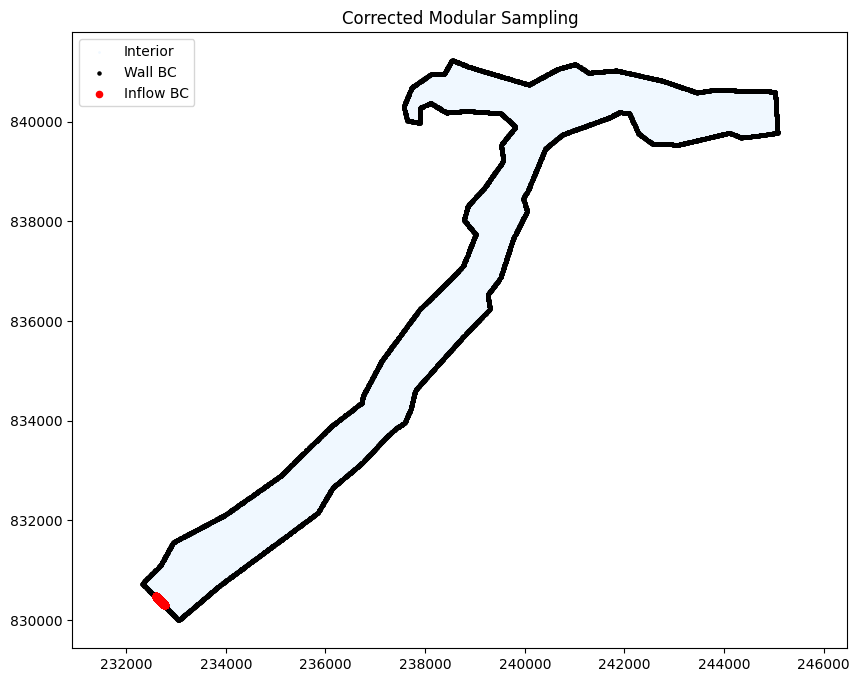

In [6]:
import os
import sys
import matplotlib.pyplot as plt
import jax
import src.config
import jax.numpy as jnp

# Ensure DTYPE is set
src.config.DTYPE = jnp.float32
from src.data import IrregularDomainSampler

# Path to the NEW artifacts (generated by your successful preprocessing run)
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz"

def main():
    print("Initializing Sampler...")
    # Direct load - no compatibility wrappers needed!
    sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    
    print(f"Found boundaries: {list(sampler.boundaries.keys())}")

    # Generate samples
    key = jax.random.PRNGKey(42)
    k1, k2, k3 = jax.random.split(key, 3)
    
    # 1. PDE
    pts_pde = sampler.sample_interior(k1, 500000, (0,1))
    
    # 2. Wall (The Domain)
    pts_wall = sampler.sample_boundary(k2, 10000, (0,1), 'wall')
    
    # 3. Inflow (The Polyline)
    pts_inflow = sampler.sample_boundary(k3, 5000, (0,1), 'inflow')
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(pts_pde[:,0], pts_pde[:,1], s=1, c='aliceblue', alpha=0.9, label='Interior')
    plt.scatter(pts_wall[:,0], pts_wall[:,1], s=5, c='black', label='Wall BC')
    plt.scatter(pts_inflow[:,0], pts_inflow[:,1], s=20, c='red', label='Inflow BC')
    
    plt.legend()
    plt.axis('equal')
    plt.title("Corrected Modular Sampling")
    plt.show()
    
if __name__ == "__main__":
    main()